# Detect and Remove the Outliers

In [ ]:
# Importing
import sklearn
from sklearn.datasets import fetch_california_housing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset
file_path='/content/online_shoppers_intention.csv'

# Create the dataframe
df = pd.read_csv(file_path)
print(df.shape)
df.head(12331)


(12330, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.000000,0.100000,0.000000,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.050000,0.140000,0.000000,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.020000,0.050000,0.000000,0.0,Feb,3,3,1,4,Returning_Visitor,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12325,3,145.0,0,0.0,53,1783.791667,0.007143,0.029031,12.241717,0.0,Dec,4,6,1,1,Returning_Visitor,True,False
12326,0,0.0,0,0.0,5,465.750000,0.000000,0.021333,0.000000,0.0,Nov,3,2,1,8,Returning_Visitor,True,False
12327,0,0.0,0,0.0,6,184.250000,0.083333,0.086667,0.000000,0.0,Nov,3,2,1,13,Returning_Visitor,True,False
12328,4,75.0,0,0.0,15,346.000000,0.000000,0.021053,0.000000,0.0,Nov,2,2,3,11,Returning_Visitor,False,False


# Method 1: Using Visualization techniques
Outliers can be detected using visualization techniques like boxplot and scatter plots

a. Using BoxPlot
It captures the summary of the data effectively and efficiently with only a simple box and whiskers. Boxplot summarizes sample data using 25th, 50th, and 75th percentiles. One can just get insights(quartiles, median, and outliers) into the dataset by just looking at its boxplot.

{'whiskers': [<matplotlib.lines.Line2D at 0x7fd79e53c490>,
 'caps': [<matplotlib.lines.Line2D at 0x7fd79e5df730>,
 'boxes': [<matplotlib.lines.Line2D at 0x7fd79e53c730>],
 'medians': [<matplotlib.lines.Line2D at 0x7fd79e5df2b0>],
 'fliers': [<matplotlib.lines.Line2D at 0x7fd79e5de650>],
 'means': []}

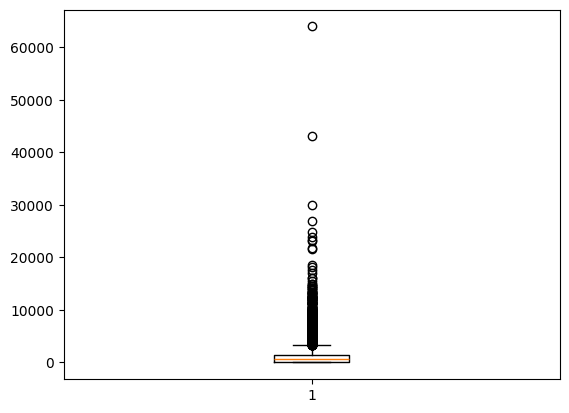

In [ ]:
import seaborn as sns
plt.boxplot(df['ProductRelated_Duration'])

In [ ]:
# Position of the Outlier
print(np.where(df['ProductRelated_Duration']>30000))

(array([5152, 8071]),)


b. ScatterPlot: It is used when you have paired numerical data, or when your dependent variable has multiple values for each reading independent variable, or when trying to determine the relationship between the two variables. In the process of utilizing the scatter plot, one can also use it for outlier detection.

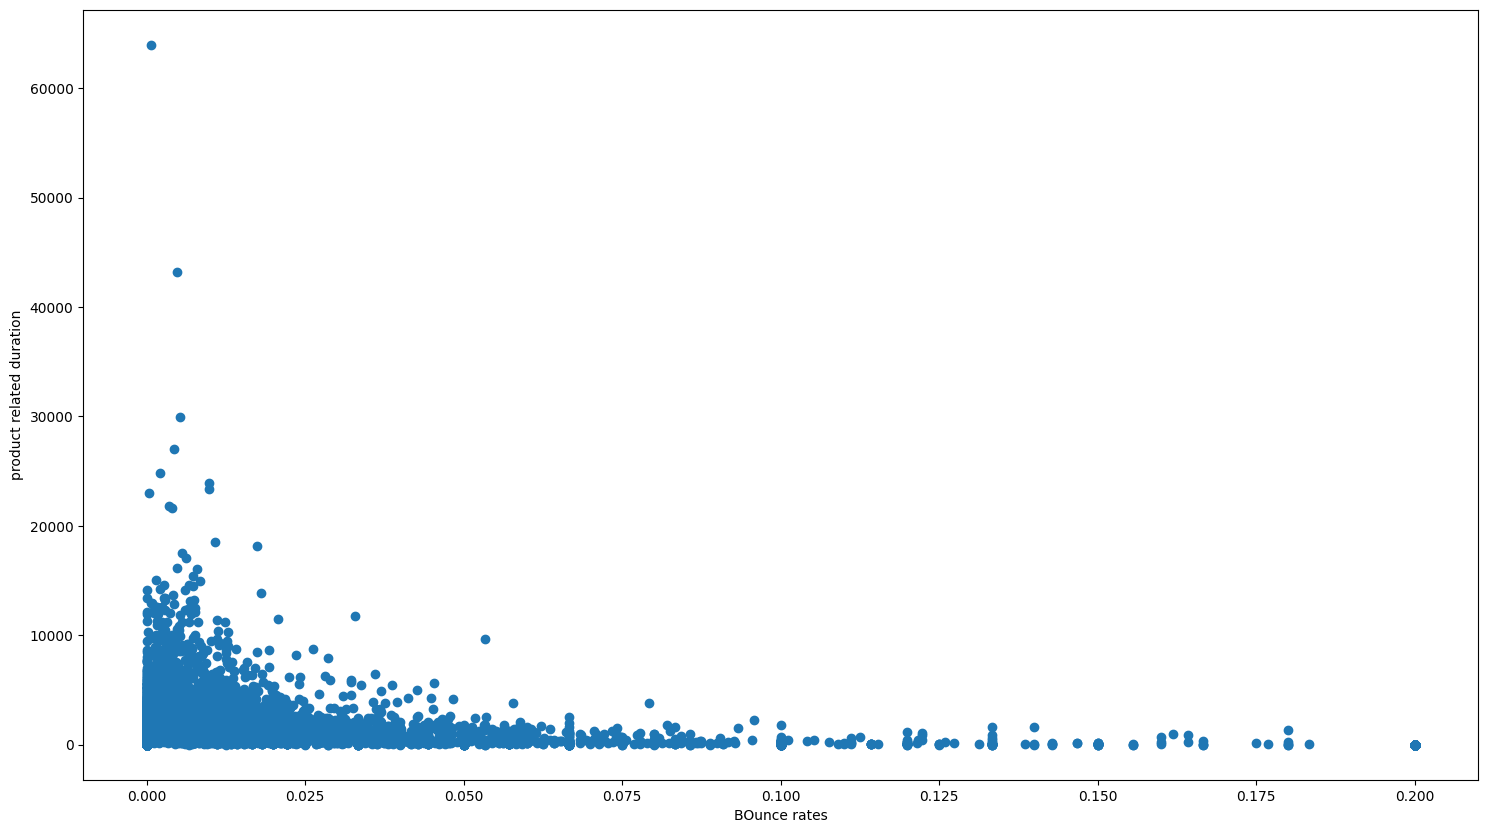

In [ ]:
#To plot the scatter plot one requires two variables that are somehow related to each other.
#So here, ‘Proportion of non-retail business acres per town’ and
#‘Full-value property-tax rate per $10,000’ are used
#whose column names are “INDUS” and “TAX” respectively.
# Scatter plot
fig, ax = plt.subplots(figsize = (18,10))
ax.scatter(df['BounceRates'], df['ProductRelated_Duration'])

# x-axis label
ax.set_xlabel('BOunce rates')

# y-axis label
ax.set_ylabel('product related duration')
plt.show()

Looking at the graph can summarize that most of the data points are in the bottom left corner of the graph but there are few points that are exactly;y opposite that is the top right corner of the graph. Those points in the top right corner can be regarded as Outliers.

Using approximation can say all those data points that are x>20 and y>600 are outliers.

In [ ]:
# Position of the Outlier
print(np.where((df['BounceRates']>0.18)))
 #print(np.where((df['ProductRelated_Duration']>30000)))

(array([    0,     2,     6,     7,    16,    21,    24,    49,    50,
          55,    56,    64,    67,    69,    70,    78,    79,    84,
          85,    91,   111,   112,   125,   132,   140,   143,   151,
         156,   158,   159,   173,   178,   181,   182,   190,   252,
         261,   271,   286,   293,   298,   302,   330,   341,   344,
         356,   359,   383,   398,   418,   421,   426,   429,   456,
         458,   468,   479,   483,   512,   515,   532,   540,   554,
         577,   585,   589,   591,   638,   658,   659,   670,   720,
         724,   727,   743,   763,   774,   804,   805,   822,   831,
         870,   872,   889,   897,   922,   929,   933,   942,   945,
         947,   956,   974,   993,  1004,  1022,  1023,  1034,  1047,
        1059,  1118,  1119,  1123,  1133,  1142,  1143,  1154,  1169,
        1170,  1172,  1176,  1180,  1213,  1214,  1236,  1265,  1285,
        1291,  1325,  1332,  1356,  1363,  1366,  1381,  1389,  1390,
        1394,  1396

# Method 2: Using Z-score
Z- Score is also called a standard score. This value/score helps to understand that how far is the data point from the mean. And after setting up a threshold value one can utilize z score values of data points to define the outliers.

In [ ]:
# Z score
from scipy import stats
import numpy as np

z = np.abs(stats.zscore(df['ProductRelated_Duration']))
print(z)

0        0.624348
1        0.590903
2        0.624348
3        0.622954
4        0.296430
           ...   
12325    0.307822
12326    0.380957
12327    0.528063
12328    0.443536
12329    0.613243
Name: ProductRelated_Duration, Length: 12330, dtype: float64


Now to define an outlier threshold value is chosen which is generally 3.0. As 99.7% of the data points lie between +/- 3 standard deviation (using Gaussian Distribution approach).

In [ ]:
#threshold = 3

# Position of the outlier
print(np.where(z > 3))

(array([   66,   510,   799,   979,  1037,  1146,  1207,  1556,  1846,
        1855,  2133,  2414,  2415,  2560,  2564,  2590,  2599,  2645,
        2824,  2890,  2939,  2969,  3561,  3809,  4226,  4253,  4326,
        4629,  4674,  4933,  5045,  5152,  5425,  5639,  5679,  5755,
        5807,  5891,  5916,  5971,  5990,  6046,  6066,  6086,  6098,
        6103,  6165,  6170,  6248,  6278,  6322,  6335,  6337,  6422,
        6474,  6488,  6519,  6550,  6603,  6674,  6684,  6733,  6762,
        6770,  6787,  6797,  6820,  6862,  6941,  6992,  6998,  7290,
        7292,  7321,  7432,  7589,  7662,  7679,  7828,  7900,  7925,
        8071,  8093,  8094,  8125,  8230,  8238,  8278,  8308,  8355,
        8415,  8438,  8485,  8548,  8557,  8602,  8612,  8618,  8630,
        8655,  8725,  8764,  8784,  8830,  8872,  8877,  8878,  8883,
        8947,  8972,  9005,  9035,  9122,  9156,  9195,  9238,  9248,
        9298,  9371,  9400,  9483,  9484,  9539,  9576,  9688,  9704,
        9705,  9709

# Method 3: Inter Quartile Range
Inter Quartile Range approach to finding the outliers is the most commonly used and most trusted approach used in the research field.

In [ ]:
# IQR
import numpy as np
Q1 = np.percentile(df['ProductRelated_Duration'], 25,
                   interpolation = 'midpoint')

Q3 = np.percentile(df['ProductRelated_Duration'], 75,
                   interpolation = 'midpoint')
IQR = Q3 - Q1

To define the outlier base value is defined above and below datasets normal range namely Upper and Lower bounds, define the upper and the lower bound (1.5*IQR value is considered) :

upper = Q3 +1.5*IQR

lower = Q1 – 1.5*IQR

In [ ]:
# Upper bound
upper = np.where(df['ProductRelated_Duration'] >= (Q3+1.5*IQR))
print(upper)
# Lower bound
lower = np.where(df['ProductRelated_Duration'] <= (Q1-1.5*IQR))
print(lower)

(array([   40,    66,   109,   195,   251,   265,   277,   334,   367,
         424,   470,   477,   499,   510,   575,   611,   619,   722,
         739,   769,   799,   825,   853,   884,   912,   952,   968,
         979,  1036,  1037,  1102,  1117,  1146,  1182,  1185,  1196,
        1207,  1233,  1324,  1339,  1499,  1519,  1554,  1556,  1564,
        1572,  1598,  1732,  1770,  1793,  1833,  1846,  1855,  1882,
        1958,  1973,  1986,  2011,  2040,  2045,  2071,  2073,  2093,
        2096,  2103,  2109,  2133,  2143,  2190,  2203,  2204,  2217,
        2219,  2256,  2262,  2301,  2372,  2387,  2397,  2414,  2415,
        2428,  2457,  2464,  2525,  2535,  2560,  2564,  2568,  2581,
        2590,  2595,  2599,  2633,  2645,  2744,  2746,  2824,  2825,
        2890,  2902,  2921,  2929,  2939,  2941,  2969,  2970,  2996,
        3029,  3091,  3114,  3127,  3156,  3178,  3179,  3185,  3228,
        3236,  3253,  3263,  3308,  3313,  3347,  3369,  3397,  3405,
        3439,  3453

In [ ]:
df['ProductRelated_Duration'] >= (Q3+1.5*IQR)

,ProductRelated_Duration
0,False
1,False
2,False
3,False
4,False
...,...
12325,False
12326,False
12327,False
12328,False


In [ ]:
#Removing the Outliers
df.drop(upper[0], inplace = True)
df.drop(lower[0], inplace = True)

print("New Shape: ", df.shape)

New Shape:  (11369, 18)


# Method 4: Isolation Forests
The IsolationForest ‘isolates’ observations by randomly selecting a feature and then randomly selecting a split value between the maximum and minimum values of the selected feature.

Since recursive partitioning can be represented by a tree structure, the number of splittings required to isolate a sample is equivalent to the path length from the root node to the terminating node.

This path length, averaged over a forest of such random trees, is a measure of normality and our decision function.

Random partitioning produces noticeably shorter paths for anomalies. Hence, when a forest of random trees collectively produce shorter path lengths for particular samples, they are highly likely to be anomalies.

In [ ]:
from sklearn.ensemble import IsolationForest
df1=np.array(df['ProductRelated_Duration']).reshape(-1,1)
clf = IsolationForest(random_state=0).fit(df1)
clf.predict(df1)


array([ 1,  1,  1, ...,  1,  1, -1])

In [ ]:
import pandas as pd
df=pd.read_csv("online_shoppers_intention.csv")
df

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.000000,0.100000,0.000000,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.050000,0.140000,0.000000,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.020000,0.050000,0.000000,0.0,Feb,3,3,1,4,Returning_Visitor,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12325,3,145.0,0,0.0,53,1783.791667,0.007143,0.029031,12.241717,0.0,Dec,4,6,1,1,Returning_Visitor,True,False
12326,0,0.0,0,0.0,5,465.750000,0.000000,0.021333,0.000000,0.0,Nov,3,2,1,8,Returning_Visitor,True,False
12327,0,0.0,0,0.0,6,184.250000,0.083333,0.086667,0.000000,0.0,Nov,3,2,1,13,Returning_Visitor,True,False
12328,4,75.0,0,0.0,15,346.000000,0.000000,0.021053,0.000000,0.0,Nov,2,2,3,11,Returning_Visitor,False,False


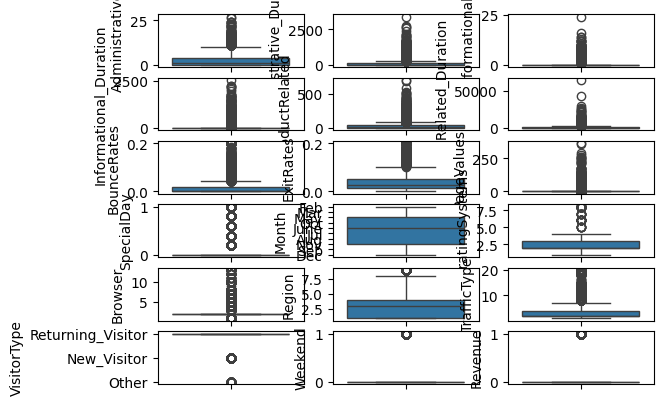

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
c=1
for i in df.columns:
    subplot=plt.subplot(6,3,c)
    sns.boxplot(df[i])
    c+=1
